# Support Vector Machine : Classify Iris Dataset

**You are given a CSV file that contains Iris flower **sepal_length, sepal_width, petal_length, petal_width** and their **species**.

Design ML model that can make prediction on **species** based on **sepal_length, sepal_width, petal_length, petal_width**.


Steps:

```
--> Collect data
--> Split into training + testing
--> Feed training data to model (i.e. train the model)
--> Evaluate the model by feeding testing data
```


## collect the data

In [1]:
import pandas as pd

df = pd.read_csv("data_iris.csv")
print(df.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


In [31]:
# shape of dataset:
print(df.shape) # rows, cols

(150, 5)


In [2]:
# lets see value counts of all 3 species
print(df["species"].value_counts())

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [ ]:
# 2

In [3]:
# Separate features and target
X = df.drop('species', axis=1)
y = df['species']

## Split data into training + testing

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

In [6]:
# Lets see how many records are in training and testing dataset

print("X_train shape:", X_train.shape)
print(f"X_test shape:", X_test.shape)

X_train shape: (105, 4)
X_test shape: (45, 4)


In [ ]:
# 3

## Feed training data to the model (i.e. train the model)

In [7]:
from sklearn.svm import SVC # Support Vector Classifier

model = SVC()

# Train the model. This can take long time depending on size of training data
model.fit(X_train, y_train) 

SVC()

In [8]:
# step1: Lets make prediction on 2 data points that I copied
X_sample = [
    [5.1, 3.5, 1.4, 0.2],   # actually setosa
    [6.3, 3.3, 6,   2.5]    # actually virginica
]

X_df = pd.DataFrame(X_sample, columns=X_train.columns)

prediction = model.predict(X_df)

print("The prediction is", prediction)

The prediction is ['setosa' 'virginica']


In [ ]:
# 6

## Evaluate the model by feeding the testing data

In [9]:
# Predict on test data
y_pred = model.predict(X_test)
print(y_pred)

['setosa' 'virginica' 'virginica' 'setosa' 'versicolor' 'versicolor'
 'virginica' 'virginica' 'versicolor' 'setosa' 'setosa' 'setosa'
 'versicolor' 'setosa' 'setosa' 'setosa' 'versicolor' 'versicolor'
 'setosa' 'virginica' 'virginica' 'setosa' 'virginica' 'versicolor'
 'versicolor' 'versicolor' 'virginica' 'virginica' 'virginica'
 'versicolor' 'setosa' 'setosa' 'setosa' 'virginica' 'versicolor' 'setosa'
 'virginica' 'versicolor' 'setosa' 'versicolor' 'versicolor' 'versicolor'
 'versicolor' 'setosa' 'virginica']


In [10]:
# lets check the prediction on first 5 data points of X_test
print(X_test[:5])
print(y_pred[:5])

     sepal_length  sepal_width  petal_length  petal_width
26            5.0          3.4           1.6          0.4
110           6.5          3.2           5.1          2.0
145           6.7          3.0           5.2          2.3
32            5.2          4.1           1.5          0.1
73            6.1          2.8           4.7          1.2
['setosa' 'virginica' 'virginica' 'setosa' 'versicolor']


In [13]:
# Lets compare the predicted vs actual value on test data
print("actual :", y_test[:5].values)
print("predict:", y_pred[:5])

predict: ['setosa' 'virginica' 'virginica' 'setosa' 'versicolor']
actual : ['setosa' 'virginica' 'virginica' 'setosa' 'versicolor']


In [14]:
# accuracy score
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9777777777777777


# OPTIONAL

In [15]:
# Check misclassified labels using confusion_matrix 

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
print("\nConfusion Matrix:")
print(cm)


Confusion Matrix:
[[16  0  0]
 [ 0 16  1]
 [ 0  0 12]]


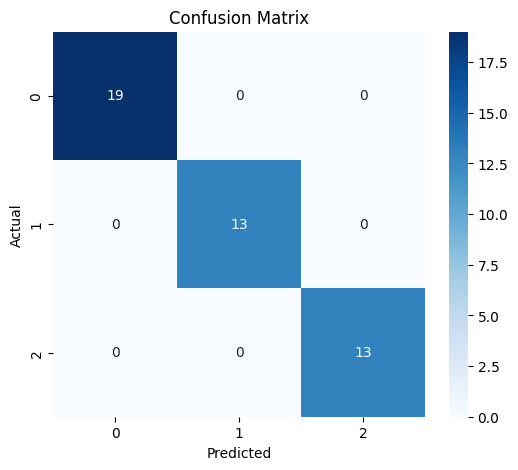

In [49]:
# Plot confusion matrix heatmap
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()